# MOMENT-1 — BTC/USDT z danych CSV

Wersja notebooka przygotowana pod Google Colab.

Najważniejsze zmiany względem wersji korzystającej bezpośrednio z Binance:
- **brak wywołań Binance API w Colabie**,
- dane OHLCV są ładowane z `btc_usdt_1h.csv`,
- preprocessing, target, chronologiczny split 70/15/15, okno 240, ewaluacja i backtest pozostają w tej samej konwencji,
- MOMENT-1 dostaje okna 240 próbek dopełnione do 512 wraz z `input_mask`.

Notebook oczekuje CSV z kolumnami:
`Date, Open, High, Low, Close, Volume`.


## 1. Instalacja w Google Colab


In [1]:
# momentfm 0.1.4 przypina starą wersję NumPy, która może być problematyczna
# na nowych runtime'ach Colaba. Instalujemy sam pakiet bez wymuszania jego
# starego NumPy i korzystamy z bibliotek dostępnych w Colabie.

%pip install -q momentfm --no-deps
%pip install -q huggingface-hub transformers einops


Po pierwszej instalacji, jeżeli import poniżej zgłosi problem związany z właśnie zainstalowanymi pakietami, wykonaj **Runtime → Restart session** i uruchom notebook ponownie od importów.


In [2]:
import copy
import random
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
)

import torch
from torch.utils.data import Dataset, DataLoader

from momentfm import MOMENTPipeline

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("PyTorch:", torch.__version__)


Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
NumPy: 2.1.3
PyTorch: 2.11.0+cu130


## 2. Konfiguracja


In [3]:
LAGS_NUM = 240
MOMENT_SEQ_LEN = 512

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

EPOCHS_NUM = 100
BATCH_SIZE = 32
PATIENCE_NUM = 10

LEARNING_RATE = 1e-5
WEIGHT_DECAY = 1e-4
MAX_GRAD_NORM = 1.0

SCALER_BOOLEAN = False

OUTPUT_VALUE = "bin_return_d2d_close"
MODEL_NAME = "AutonLab/MOMENT-1-base"

SEED = 42

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

if DEVICE.type != "cuda":
    print(
        "UWAGA: w Colabie wybierz Runtime -> Change runtime type -> GPU, "
        "aby fine-tuning był praktyczny."
    )


Device: cuda


In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)


## 3. Wczytanie CSV


In [5]:
# OPCJA A — plik wgrany bezpośrednio do sesji Colaba:
CSV_PATH = "/content/btc_usdt_1h.csv"

# OPCJA B — Google Drive:
# from google.colab import drive
# drive.mount("/content/drive")
# CSV_PATH = "/content/drive/MyDrive/btc_usdt_1h.csv"

if not Path(CSV_PATH).exists():
    raise FileNotFoundError(
        f"Nie znaleziono {CSV_PATH}. "
        "Wgraj btc_usdt_1h.csv do Colaba albo zmień CSV_PATH."
    )

data = pd.read_csv(
    CSV_PATH,
    parse_dates=["Date"],
)

required_columns = {
    "Date", "Open", "High", "Low", "Close", "Volume"
}

missing_columns = required_columns.difference(data.columns)

if missing_columns:
    raise ValueError(
        f"CSV nie zawiera wymaganych kolumn: {sorted(missing_columns)}"
    )

data = (
    data
    .drop_duplicates(subset="Date")
    .sort_values("Date")
    .set_index("Date")
)

print("Shape:", data.shape)
display(data.head())
display(data.tail())


Shape: (21097, 5)


,Open,High,Low,Close,Volume
Date,,,,,
2023-11-03 20:00:00+00:00,34530.71,34659.66,34485.65,34593.90,1046.24789
2023-11-03 21:00:00+00:00,34593.90,34700.00,34583.86,34600.93,704.45031
2023-11-03 22:00:00+00:00,34600.94,34635.25,34563.54,34628.14,645.16337
2023-11-03 23:00:00+00:00,34628.13,34740.00,34611.38,34716.78,894.85032
2023-11-04 00:00:00+00:00,34716.78,34725.00,34653.84,34696.65,654.53035


,Open,High,Low,Close,Volume
Date,,,,,
2026-03-31 16:00:00+00:00,66736.79,68030.19,66729.28,67665.83,1334.03651
2026-03-31 17:00:00+00:00,67665.83,68589.49,67403.81,67526.75,2195.81331
2026-03-31 18:00:00+00:00,67526.76,67947.98,67526.30,67854.05,426.40012
2026-03-31 19:00:00+00:00,67854.04,68029.41,67716.35,67838.80,435.24470
2026-03-31 20:00:00+00:00,67838.79,68267.27,67831.70,68265.53,693.06575


## 4. Kontrola ciągłości danych


In [6]:
all_dates = pd.date_range(
    start=data.index.min(),
    end=data.index.max(),
    freq="h",
)

missing = all_dates.difference(data.index)

print("Pierwszy timestamp:", data.index.min())
print("Ostatni timestamp:", data.index.max())
print("Brakujące timestampy:", len(missing))

if len(missing):
    display(pd.Series(missing[:50], name="missing_timestamp"))


Pierwszy timestamp: 2023-11-03 20:00:00+00:00
Ostatni timestamp: 2026-03-31 20:00:00+00:00
Brakujące timestampy: 0


## 5. Feature engineering i target


In [7]:
data["log_return_close"] = np.log(
    data["Close"] / data["Close"].shift(1)
)

data["return_close"] = (
    data["Close"] / data["Close"].shift(1) - 1
)

data["bin_return_close"] = (
    data["log_return_close"] > 0
).astype(np.int64)

data["bin_return_d2d_close"] = (
    data["log_return_close"]
    > data["log_return_close"].shift(1)
).astype(np.int64)

data = data.dropna().copy()

print(data[
    [
        "Close",
        "log_return_close",
        "return_close",
        "bin_return_close",
        "bin_return_d2d_close",
    ]
].head())


                              Close  log_return_close  return_close  \
Date                                                                  
2023-11-03 21:00:00+00:00  34600.93          0.000203      0.000203   
2023-11-03 22:00:00+00:00  34628.14          0.000786      0.000786   
2023-11-03 23:00:00+00:00  34716.78          0.002556      0.002560   
2023-11-04 00:00:00+00:00  34696.65         -0.000580     -0.000580   
2023-11-04 01:00:00+00:00  34768.15          0.002059      0.002061   

                           bin_return_close  bin_return_d2d_close  
Date                                                               
2023-11-03 21:00:00+00:00                 1                     0  
2023-11-03 22:00:00+00:00                 1                     1  
2023-11-03 23:00:00+00:00                 1                     1  
2023-11-04 00:00:00+00:00                 0                     0  
2023-11-04 01:00:00+00:00                 1                     1  


## 6. Chronologiczny split 70 / 15 / 15

Najpierw dzielimy **surowy szereg czasowy** na trzy niezależne części:

- 70% train,
- 15% validation,
- 15% test.

Dopiero **po podziale** generujemy okna `LAGS_NUM=240` osobno wewnątrz każdego splitu.

Pierwszych 240 obserwacji każdego splitu służy wyłącznie jako historia potrzebna do utworzenia pierwszego targetu. Validation i test nie pobierają kontekstu z poprzedniego splitu.

To odtwarza logikę oryginalnego notebooka LSTM i daje porównywalną liczbę próbek testowych.


In [8]:
n = len(data)

train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

if train_end <= LAGS_NUM:
    raise ValueError("Za mało danych treningowych dla wybranego LAGS_NUM.")

train_part = data.iloc[:train_end].copy()
val_part = data.iloc[train_end:val_end].copy()
test_part = data.iloc[val_end:].copy()

print("Raw train:", train_part.shape)
print("Raw val:  ", val_part.shape)
print("Raw test: ", test_part.shape)
print()
print("Train:", train_part.index.min(), "->", train_part.index.max())
print("Val:  ", val_part.index.min(), "->", val_part.index.max())
print("Test: ", test_part.index.min(), "->", test_part.index.max())


Raw train: (14767, 9)
Raw val:   (3164, 9)
Raw test:  (3165, 9)

Train: 2023-11-03 21:00:00+00:00 -> 2025-07-11 03:00:00+00:00
Val:   2025-07-11 04:00:00+00:00 -> 2025-11-19 23:00:00+00:00
Test:  2025-11-20 00:00:00+00:00 -> 2026-03-31 20:00:00+00:00


## 7. Przygotowanie cech i generowanie okien 240

Po wykonaniu chronologicznego podziału 70/15/15 przygotowujemy cechę, target,
stopy zwrotu i timestampy. Następnie okna 240 są tworzone **osobno**
wewnątrz train, validation i test.

Jeżeli `SCALER_BOOLEAN=True`, scaler jest dopasowywany wyłącznie na train,
a następnie używany do transformacji całego szeregu.


In [9]:
# Przygotowanie tablic używanych do budowy okien.
feature_all = data["log_return_close"].to_numpy(dtype=np.float32)
target_all = data[OUTPUT_VALUE].to_numpy(dtype=np.int64)
returns_all = data["return_close"].to_numpy(dtype=np.float32)
timestamps_all = data.index.to_numpy()

# Opcjonalne skalowanie.
# Scaler jest FITOWANY WYŁĄCZNIE na train.
scaler = None

if SCALER_BOOLEAN:
    scaler = StandardScaler()

    scaler.fit(
        train_part["log_return_close"]
        .to_numpy(dtype=np.float32)
        .reshape(-1, 1)
    )

    feature_all = scaler.transform(
        feature_all.reshape(-1, 1)
    ).reshape(-1).astype(np.float32)


def make_windows(
    feature_values,
    target_values,
    target_returns,
    target_timestamps,
    lags,
):
    X_out = []
    y_out = []
    returns_out = []
    timestamps_out = []

    for i in range(lags, len(feature_values)):
        X_out.append(feature_values[i-lags:i])
        y_out.append(target_values[i])
        returns_out.append(target_returns[i])
        timestamps_out.append(target_timestamps[i])

    return (
        np.asarray(X_out, dtype=np.float32).reshape(-1, lags, 1),
        np.asarray(y_out, dtype=np.int64),
        np.asarray(returns_out, dtype=np.float32),
        pd.DatetimeIndex(timestamps_out),
    )


# Split został wykonany wcześniej.
# Teraz pobieramy tablice dla każdego splitu OSOBNO.
train_features = feature_all[:train_end]
train_targets = target_all[:train_end]
train_returns_raw = returns_all[:train_end]
train_times = timestamps_all[:train_end]

val_features = feature_all[train_end:val_end]
val_targets = target_all[train_end:val_end]
val_returns_raw = returns_all[train_end:val_end]
val_times = timestamps_all[train_end:val_end]

test_features = feature_all[val_end:]
test_targets = target_all[val_end:]
test_returns_raw = returns_all[val_end:]
test_times = timestamps_all[val_end:]


# Okna powstają niezależnie wewnątrz każdego splitu.
X_train, y_train, train_returns, train_timestamps = make_windows(
    train_features,
    train_targets,
    train_returns_raw,
    train_times,
    LAGS_NUM,
)

X_val, y_val, val_returns, val_timestamps = make_windows(
    val_features,
    val_targets,
    val_returns_raw,
    val_times,
    LAGS_NUM,
)

X_test, y_test, test_returns, test_timestamps = make_windows(
    test_features,
    test_targets,
    test_returns_raw,
    test_times,
    LAGS_NUM,
)


print("PRZED tworzeniem okien:")
print("train:", len(train_features))
print("val:  ", len(val_features))
print("test: ", len(test_features))

print()
print(f"PO utworzeniu okien (LAGS_NUM={LAGS_NUM}):")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "| y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "| y_test: ", y_test.shape)

print()
print("Każdy split traci dokładnie LAGS_NUM próbek:")
print("train:", len(train_features) - LAGS_NUM)
print("val:  ", len(val_features) - LAGS_NUM)
print("test: ", len(test_features) - LAGS_NUM)

assert len(X_train) == len(train_features) - LAGS_NUM
assert len(X_val) == len(val_features) - LAGS_NUM
assert len(X_test) == len(test_features) - LAGS_NUM

assert X_train.shape[1:] == (LAGS_NUM, 1)
assert X_val.shape[1:] == (LAGS_NUM, 1)
assert X_test.shape[1:] == (LAGS_NUM, 1)


PRZED tworzeniem okien:
train: 14767
val:   3164
test:  3165

PO utworzeniu okien (LAGS_NUM=240):
X_train: (14527, 240, 1) | y_train: (14527,)
X_val:   (2924, 240, 1) | y_val:   (2924,)
X_test:  (2925, 240, 1) | y_test:  (2925,)

Każdy split traci dokładnie LAGS_NUM próbek:
train: 14527
val:   2924
test:  2925


## 8. Dataset MOMENT — padding 240 → 512 + maska


In [10]:
class MomentDataset(Dataset):

    def __init__(self, X, y, moment_seq_len=512):
        self.X = np.asarray(X, dtype=np.float32)
        self.y = np.asarray(y, dtype=np.int64).reshape(-1)
        self.moment_seq_len = moment_seq_len

        if self.X.ndim != 3:
            raise ValueError(
                f"X musi mieć shape (N, {LAGS_NUM}, 1); "
                f"otrzymano {self.X.shape}"
            )

        if self.X.shape[1] > moment_seq_len:
            raise ValueError(
                "Okno jest dłuższe niż MOMENT_SEQ_LEN."
            )

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        series = self.X[idx].squeeze(-1)

        pad_len = self.moment_seq_len - len(series)

        padded = np.pad(
            series,
            (pad_len, 0),
            mode="constant",
            constant_values=0.0,
        )

        input_mask = np.zeros(
            self.moment_seq_len,
            dtype=np.int64,
        )
        input_mask[pad_len:] = 1

        # (512,) -> (1, 512)
        padded = padded[np.newaxis, :]

        return (
            torch.tensor(padded, dtype=torch.float32),
            torch.tensor(input_mask, dtype=torch.long),
            torch.tensor(self.y[idx], dtype=torch.long),
        )


In [11]:
train_loader = DataLoader(
    MomentDataset(X_train, y_train, MOMENT_SEQ_LEN),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda"),
)

val_loader = DataLoader(
    MomentDataset(X_val, y_val, MOMENT_SEQ_LEN),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda"),
)

test_loader = DataLoader(
    MomentDataset(X_test, y_test, MOMENT_SEQ_LEN),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda"),
)

x, mask, labels = next(iter(train_loader))

print("x:", x.shape)
print("mask:", mask.shape)
print("labels:", labels.shape)


x: torch.Size([32, 1, 512])
mask: torch.Size([32, 512])
labels: torch.Size([32])


## 9. MOMENT-1-base


In [12]:
model = MOMENTPipeline.from_pretrained(
    MODEL_NAME,
    model_kwargs={
        "task_name": "classification",
        "n_channels": 1,
        "num_class": 2,
    },
)

model.init()
model = model.to(DEVICE)

for parameter in model.parameters():
    parameter.requires_grad = True

trainable_parameters = [
    p for p in model.parameters()
    if p.requires_grad
]

print(
    "Trainable parameters:",
    f"{sum(p.numel() for p in trainable_parameters):,}"
)

criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    trainable_parameters,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)


config.json:   0%|          | 0.00/949 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  454MB            

model.safetensors: downloading bytes:           |  0.00B            

/usr/local/lib/python3.13/dist-packages/momentfm/models/moment.py:174: UserWarning: Only reconstruction head is pre-trained. Classification and forecasting heads must be fine-tuned.
  warnings.warn("Only reconstruction head is pre-trained. Classification and forecasting heads must be fine-tuned.")


Trainable parameters: 109,636,994


## 10. Funkcje treningowe


In [13]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()

    loss_sum = 0.0
    correct = 0
    total = 0

    for x, input_mask, y in loader:
        x = x.to(device, non_blocking=True)
        input_mask = input_mask.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        output = model(
            x_enc=x,
            input_mask=input_mask,
        )

        logits = output.logits
        loss = criterion(logits, y)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            MAX_GRAD_NORM,
        )

        optimizer.step()

        loss_sum += loss.item() * y.size(0)

        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    return loss_sum / total, correct / total


@torch.no_grad()
def evaluate_epoch(model, loader, criterion, device):
    model.eval()

    loss_sum = 0.0
    correct = 0
    total = 0

    for x, input_mask, y in loader:
        x = x.to(device, non_blocking=True)
        input_mask = input_mask.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        output = model(
            x_enc=x,
            input_mask=input_mask,
        )

        logits = output.logits
        loss = criterion(logits, y)

        loss_sum += loss.item() * y.size(0)

        pred = logits.argmax(dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    return loss_sum / total, correct / total


## 11. Fine-tuning + Early Stopping


In [14]:
best_val_loss = np.inf
best_model_state = None
patience_counter = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": [],
}

for epoch in range(1, EPOCHS_NUM + 1):

    train_loss, train_acc = train_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        DEVICE,
    )

    val_loss, val_acc = evaluate_epoch(
        model,
        val_loader,
        criterion,
        DEVICE,
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_accuracy"].append(train_acc)
    history["val_accuracy"].append(val_acc)

    print(
        f"Epoch {epoch:03d}/{EPOCHS_NUM} | "
        f"train loss={train_loss:.4f} | "
        f"train acc={train_acc:.4f} | "
        f"val loss={val_loss:.4f} | "
        f"val acc={val_acc:.4f}"
    )

    # Monitorujemy val_loss zamiast accuracy — zwykle daje stabilniejszy
    # sygnał do early stopping.
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(
            model.state_dict()
        )
        patience_counter = 0
        print("  -> zapisano najlepszy model")
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE_NUM:
        print(f"Early stopping po {epoch} epokach.")
        break

if best_model_state is None:
    raise RuntimeError("Nie zapisano żadnego stanu modelu.")

model.load_state_dict(best_model_state)

print(
    f"Przywrócono najlepszy model; "
    f"val_loss={best_val_loss:.4f}"
)


Epoch 001/100 | train loss=0.6291 | train acc=0.6131 | val loss=0.5228 | val acc=0.7503
  -> zapisano najlepszy model
Epoch 002/100 | train loss=0.5204 | train acc=0.7457 | val loss=0.5199 | val acc=0.7469
  -> zapisano najlepszy model
Epoch 003/100 | train loss=0.5114 | train acc=0.7526 | val loss=0.5236 | val acc=0.7483
Epoch 004/100 | train loss=0.4980 | train acc=0.7603 | val loss=0.5286 | val acc=0.7551
Epoch 005/100 | train loss=0.4879 | train acc=0.7665 | val loss=0.5550 | val acc=0.7285
Epoch 006/100 | train loss=0.4744 | train acc=0.7767 | val loss=0.5607 | val acc=0.7380
Epoch 007/100 | train loss=0.4585 | train acc=0.7879 | val loss=0.5694 | val acc=0.7401
Epoch 008/100 | train loss=0.4441 | train acc=0.7932 | val loss=0.5761 | val acc=0.7319
Epoch 009/100 | train loss=0.4230 | train acc=0.8082 | val loss=0.6215 | val acc=0.7196
Epoch 010/100 | train loss=0.4089 | train acc=0.8155 | val loss=0.6634 | val acc=0.7226
Epoch 011/100 | train loss=0.3845 | train acc=0.8302 | val l

## 12. Krzywe treningu


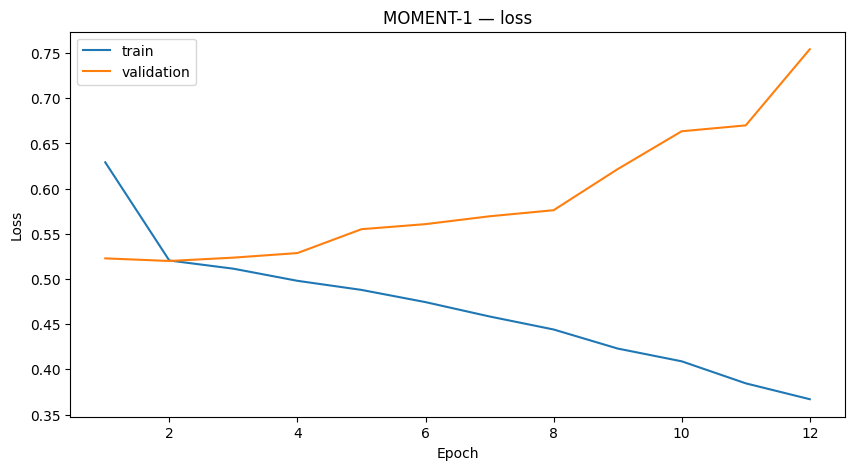

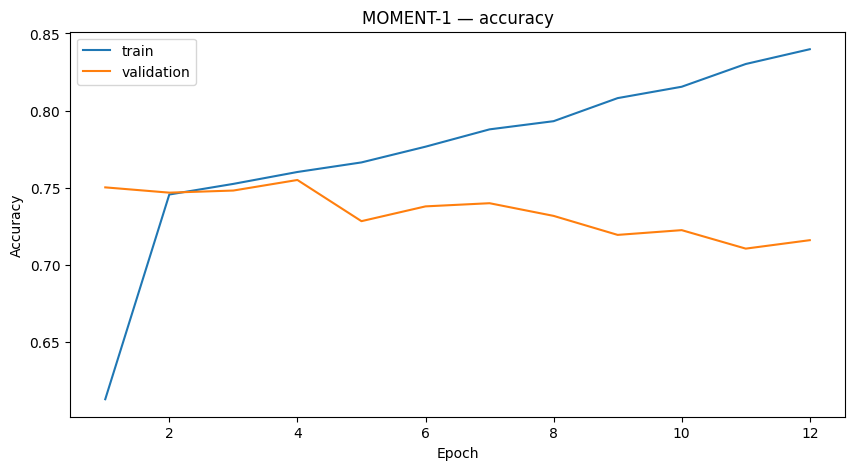

In [15]:
epochs = np.arange(
    1,
    len(history["train_loss"]) + 1
)

plt.figure(figsize=(10, 5))
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["val_loss"], label="validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MOMENT-1 — loss")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs, history["train_accuracy"], label="train")
plt.plot(epochs, history["val_accuracy"], label="validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MOMENT-1 — accuracy")
plt.legend()
plt.show()


## 13. Predykcja i metryki testowe


In [16]:
@torch.no_grad()
def predict(model, loader, device):
    model.eval()

    y_true = []
    y_pred = []
    y_prob = []

    for x, input_mask, y in loader:
        x = x.to(device, non_blocking=True)
        input_mask = input_mask.to(device, non_blocking=True)

        output = model(
            x_enc=x,
            input_mask=input_mask,
        )

        probabilities = torch.softmax(
            output.logits,
            dim=1,
        )

        predictions = probabilities.argmax(dim=1)

        y_true.extend(y.numpy())
        y_pred.extend(predictions.cpu().numpy())
        y_prob.extend(probabilities[:, 1].cpu().numpy())

    return (
        np.asarray(y_true),
        np.asarray(y_pred),
        np.asarray(y_prob),
    )


y_true, y_pred, y_prob = predict(
    model,
    test_loader,
    DEVICE,
)

print(
    classification_report(
        y_true,
        y_pred,
        digits=4,
    )
)

if len(np.unique(y_true)) == 2:
    print(
        "ROC-AUC:",
        round(roc_auc_score(y_true, y_prob), 4)
    )


              precision    recall  f1-score   support

           0     0.7192    0.7933    0.7544      1485
           1     0.7615    0.6806    0.7187      1440

    accuracy                         0.7378      2925
   macro avg     0.7403    0.7369    0.7366      2925
weighted avg     0.7400    0.7378    0.7368      2925

ROC-AUC: 0.8125


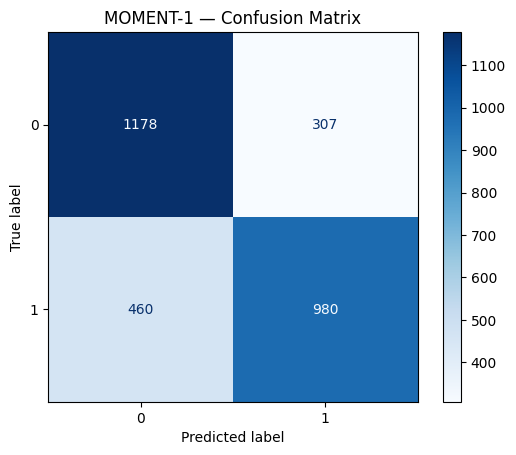

In [17]:
ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=["0", "1"],
    cmap="Blues",
)

plt.title("MOMENT-1 — Confusion Matrix")
plt.show()


## 14. Backtest — model, Momentum i Random


MODEL: MOMENT-1
Observations: 2925
Bets: 810 | Bet Frequency: 0.2769
Bet Accuracy: 0.5136
UP Accuracy: 0.4937 | DOWN Accuracy: 0.5218
Confirmed Accuracy: 0.3000 (20 bets)
Neutral Accuracy: 0.5190 (790 bets)
Final Cash: 1220.00 USDT
Total Return: 22.00%
Annualized Sharpe: 1.6014
Bankrupt: False


,Strategy,Number of Bets,Bet Frequency,Bet Accuracy,Final Cash,Total Return (%),Sharpe Ratio,Bankrupt
0,MOMENT-1,810,0.2769,0.5136,1220.0,22.0,1.6014,False
1,Momentum,2156,0.7371,0.4768,0.0,-100.0,-2.4619,True
2,Random,810,0.2769,0.5074,1120.0,12.0,0.9050,False



First executed model bets:


,previous_return,prediction,future_return,signal_type,decision,pnl_usd,cash
2025-11-30 00:00:00+00:00,0.000544,0,0.001007,NEUTRAL,DOWN,-10.0,990.0
2025-11-30 02:00:00+00:00,0.000213,0,-0.001297,NEUTRAL,DOWN,10.0,1000.0
2025-11-30 05:00:00+00:00,-0.000565,0,-0.000818,NEUTRAL,DOWN,10.0,1010.0
2025-11-30 06:00:00+00:00,-0.000818,1,0.001265,NEUTRAL,UP,10.0,1020.0
2025-11-30 08:00:00+00:00,0.000764,0,0.002375,NEUTRAL,DOWN,-10.0,1010.0
2025-11-30 16:00:00+00:00,-0.000707,1,0.004255,NEUTRAL,UP,10.0,1020.0
2025-11-30 19:00:00+00:00,-0.000309,0,0.000010,NEUTRAL,DOWN,-10.0,1010.0
2025-11-30 20:00:00+00:00,0.000010,0,-0.001589,NEUTRAL,DOWN,10.0,1020.0
2025-11-30 23:00:00+00:00,0.000560,0,-0.009530,NEUTRAL,DOWN,10.0,1030.0
2025-12-01 11:00:00+00:00,-0.000659,1,-0.005771,NEUTRAL,UP,-10.0,1020.0


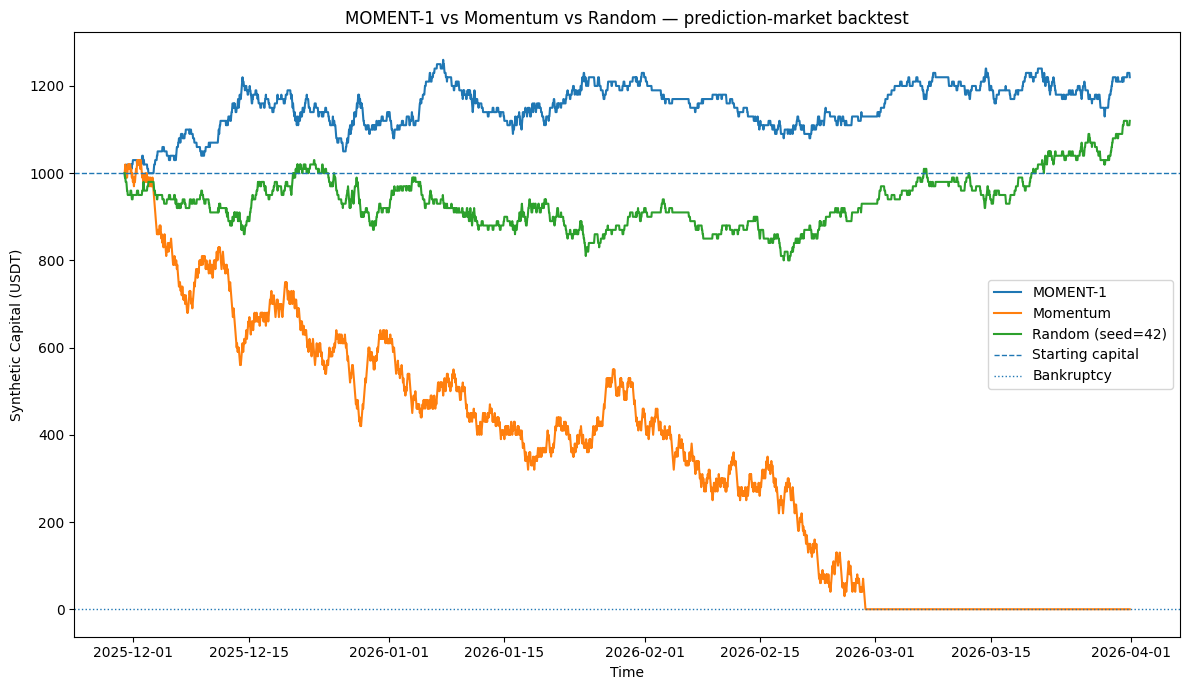

In [18]:
# ============================================================
# FINAL BACKTESTING - PREDICTION MARKET
# MOMENT-1 + MOMENTUM + RANDOM BENCHMARK
# ============================================================

EPSILON = 0.001
START_CASH = 1000.0
BET_PAYOUT = 10.0
RISK_FREE_ANNUAL = 0.0
RANDOM_SEED = 42

# ------------------------------------------------------------
# 1. ALIGN PREDICTIONS WITH r_t AND r_(t+1)
# ------------------------------------------------------------
# make_windows() creates the first test target at index LAGS_NUM.
# Therefore, for every prediction of y_(t+1):
#   previous_return = r_t     -> raw log return at i-1
#   future_return   = r_(t+1) -> raw log return at i
# We use RAW log returns here (not scaled features), consistently
# with the definition of bin_return_d2d_close.

predictions = np.asarray(y_pred).ravel().astype(int)
if len(predictions) == 0 or not np.isin(predictions, [0, 1]).all():
    raise ValueError("Predictions must be a non-empty binary array containing only 0 and 1.")

test_log_returns_raw = (
    data["log_return_close"]
    .iloc[val_end:]
    .to_numpy(dtype=float)
)

previous_returns = test_log_returns_raw[LAGS_NUM - 1:-1]
future_returns = test_log_returns_raw[LAGS_NUM:]
backtest_index = pd.DatetimeIndex(test_timestamps)

if not (len(predictions) == len(previous_returns) == len(future_returns) == len(backtest_index)):
    raise ValueError(
        "Alignment error: "
        f"predictions={len(predictions)}, previous={len(previous_returns)}, "
        f"future={len(future_returns)}, timestamps={len(backtest_index)}"
    )
if not (np.isfinite(previous_returns).all() and np.isfinite(future_returns).all()):
    raise ValueError("Backtest returns contain non-finite values.")

# Optional consistency check: target reconstructed from raw returns
# must be identical to y_test used for model evaluation.
reconstructed_target = (future_returns > previous_returns).astype(int)
if not np.array_equal(reconstructed_target, np.asarray(y_test).ravel().astype(int)):
    raise ValueError("Target alignment check failed: reconstructed d2d target != y_test.")

# ------------------------------------------------------------
# 2. HELPERS
# ------------------------------------------------------------

def annualized_sharpe(equity, periods_per_year=365 * 24, risk_free_annual=0.0):
    equity = np.asarray(equity, dtype=float)
    if len(equity) < 3:
        return np.nan

    prev = equity[:-1]
    curr = equity[1:]
    valid = prev > 0
    if valid.sum() < 2:
        return np.nan

    returns = (curr[valid] - prev[valid]) / prev[valid]
    rf_per_period = np.expm1(np.log1p(risk_free_annual) / periods_per_year)
    excess = returns - rf_per_period
    volatility = excess.std(ddof=1)
    if np.isclose(volatility, 0.0):
        return np.nan
    return np.sqrt(periods_per_year) * excess.mean() / volatility

def settle(direction, future_return):
    if direction == "UP":
        return BET_PAYOUT if future_return > 0 else -BET_PAYOUT
    if direction == "DOWN":
        return BET_PAYOUT if future_return < 0 else -BET_PAYOUT
    return 0.0

def apply_pnl(cash, pnl):
    # A loss cannot push capital below zero.
    if pnl < 0:
        pnl = -min(abs(pnl), cash)
    return max(cash + pnl, 0.0), pnl

# ------------------------------------------------------------
# 3. MODEL STRATEGY
# ------------------------------------------------------------

cash = START_CASH
cash_history = [cash]
pnl_history = []
decision_history = []
signal_type_history = []
bankrupt = False

bets = wins = losses = 0
up_bets = down_bets = up_wins = down_wins = 0
confirmed_bets = confirmed_wins = 0
neutral_bets = neutral_wins = 0

for prediction, previous_return, future_return in zip(
    predictions, previous_returns, future_returns
):
    if bankrupt or cash <= 0:
        bankrupt = True
        decision_history.append("BANKRUPT")
        signal_type_history.append("BANKRUPT")
        pnl_history.append(0.0)
        cash_history.append(0.0)
        continue

    decision = "NO BET"
    signal_type = "NO BET"

    if previous_return > EPSILON and prediction == 1:
        decision = "UP"
        signal_type = "CONFIRMED"
    elif previous_return < -EPSILON and prediction == 0:
        decision = "DOWN"
        signal_type = "CONFIRMED"
    elif abs(previous_return) <= EPSILON:
        decision = "UP" if prediction == 1 else "DOWN"
        signal_type = "NEUTRAL"

    pnl = 0.0
    if decision in ("UP", "DOWN"):
        bets += 1
        if decision == "UP":
            up_bets += 1
        else:
            down_bets += 1

        if signal_type == "CONFIRMED":
            confirmed_bets += 1
        else:
            neutral_bets += 1

        pnl = settle(decision, future_return)
        if pnl > 0:
            wins += 1
            if decision == "UP":
                up_wins += 1
            else:
                down_wins += 1
            if signal_type == "CONFIRMED":
                confirmed_wins += 1
            else:
                neutral_wins += 1
        else:
            losses += 1

        cash, pnl = apply_pnl(cash, pnl)
        if cash <= 0:
            bankrupt = True

    decision_history.append(decision)
    signal_type_history.append(signal_type)
    pnl_history.append(pnl)
    cash_history.append(cash)

# ------------------------------------------------------------
# 4. MOMENTUM BENCHMARK
# ------------------------------------------------------------

momentum_cash = START_CASH
momentum_cash_history = [momentum_cash]
momentum_bets = momentum_wins = 0
momentum_bankrupt = False

for previous_return, future_return in zip(previous_returns, future_returns):
    if momentum_bankrupt or momentum_cash <= 0:
        momentum_bankrupt = True
        momentum_cash_history.append(0.0)
        continue

    direction = "UP" if previous_return > 0 else ("DOWN" if previous_return < 0 else "NO BET")
    if direction in ("UP", "DOWN"):
        momentum_bets += 1
        pnl = settle(direction, future_return)
        if pnl > 0:
            momentum_wins += 1
        momentum_cash, _ = apply_pnl(momentum_cash, pnl)
        if momentum_cash <= 0:
            momentum_bankrupt = True

    momentum_cash_history.append(momentum_cash)

# ------------------------------------------------------------
# 5. RANDOM BENCHMARK
# Same potential entry timestamps as the model; one fixed seed.
# ------------------------------------------------------------

rng = np.random.default_rng(RANDOM_SEED)
random_cash = START_CASH
random_cash_history = [random_cash]
random_bets = random_wins = 0
random_bankrupt = False

for model_decision, future_return in zip(decision_history, future_returns):
    if random_bankrupt or random_cash <= 0:
        random_bankrupt = True
        random_cash_history.append(0.0)
        continue

    if model_decision in ("UP", "DOWN"):
        direction = "UP" if rng.integers(0, 2) == 1 else "DOWN"
        random_bets += 1
        pnl = settle(direction, future_return)
        if pnl > 0:
            random_wins += 1
        random_cash, _ = apply_pnl(random_cash, pnl)
        if random_cash <= 0:
            random_bankrupt = True

    random_cash_history.append(random_cash)

# ------------------------------------------------------------
# 6. METRICS
# ------------------------------------------------------------

n_obs = len(predictions)
model_accuracy = wins / bets if bets else np.nan
model_bet_frequency = bets / n_obs if n_obs else np.nan
up_accuracy = up_wins / up_bets if up_bets else np.nan
down_accuracy = down_wins / down_bets if down_bets else np.nan
confirmed_accuracy = confirmed_wins / confirmed_bets if confirmed_bets else np.nan
neutral_accuracy = neutral_wins / neutral_bets if neutral_bets else np.nan

model_sharpe = annualized_sharpe(cash_history, risk_free_annual=RISK_FREE_ANNUAL)
momentum_sharpe = annualized_sharpe(momentum_cash_history, risk_free_annual=RISK_FREE_ANNUAL)
random_sharpe = annualized_sharpe(random_cash_history, risk_free_annual=RISK_FREE_ANNUAL)

comparison = pd.DataFrame({
    "Strategy": ["MOMENT-1", "Momentum", "Random"],
    "Number of Bets": [bets, momentum_bets, random_bets],
    "Bet Frequency": [
        model_bet_frequency,
        momentum_bets / n_obs if n_obs else np.nan,
        random_bets / n_obs if n_obs else np.nan,
    ],
    "Bet Accuracy": [
        model_accuracy,
        momentum_wins / momentum_bets if momentum_bets else np.nan,
        random_wins / random_bets if random_bets else np.nan,
    ],
    "Final Cash": [cash, momentum_cash, random_cash],
    "Total Return (%)": [
        (cash / START_CASH - 1) * 100,
        (momentum_cash / START_CASH - 1) * 100,
        (random_cash / START_CASH - 1) * 100,
    ],
    "Sharpe Ratio": [model_sharpe, momentum_sharpe, random_sharpe],
    "Bankrupt": [bankrupt, momentum_bankrupt, random_bankrupt],
})

print(f"MODEL: MOMENT-1")
print(f"Observations: {n_obs}")
print(f"Bets: {bets} | Bet Frequency: {model_bet_frequency:.4f}")
print(f"Bet Accuracy: {model_accuracy:.4f}")
print(f"UP Accuracy: {up_accuracy:.4f} | DOWN Accuracy: {down_accuracy:.4f}")
print(f"Confirmed Accuracy: {confirmed_accuracy:.4f} ({confirmed_bets} bets)")
print(f"Neutral Accuracy: {neutral_accuracy:.4f} ({neutral_bets} bets)")
print(f"Final Cash: {cash:.2f} USDT")
print(f"Total Return: {(cash / START_CASH - 1) * 100:.2f}%")
print(f"Annualized Sharpe: {model_sharpe:.4f}")
print(f"Bankrupt: {bankrupt}")

display(comparison.round({
    "Bet Frequency": 4,
    "Bet Accuracy": 4,
    "Final Cash": 2,
    "Total Return (%)": 2,
    "Sharpe Ratio": 4,
}))

# Detailed model decisions
backtest_results = pd.DataFrame({
    "previous_return": previous_returns,
    "prediction": predictions,
    "future_return": future_returns,
    "signal_type": signal_type_history,
    "decision": decision_history,
    "pnl_usd": pnl_history,
    "cash": cash_history[1:],
}, index=backtest_index)

print("\nFirst executed model bets:")
display(backtest_results[backtest_results["decision"].isin(["UP", "DOWN"])].head(10))

# ------------------------------------------------------------
# 7. EQUITY CURVES
# ------------------------------------------------------------
curve_index = pd.DatetimeIndex([backtest_index[0] - pd.Timedelta(hours=1)]).append(backtest_index)

plt.figure(figsize=(12, 7))
plt.plot(curve_index, cash_history, label="MOMENT-1")
plt.plot(curve_index, momentum_cash_history, label="Momentum")
plt.plot(curve_index, random_cash_history, label="Random (seed=42)")
plt.axhline(START_CASH, linestyle="--", linewidth=1, label="Starting capital")
plt.axhline(0, linestyle=":", linewidth=1, label="Bankruptcy")
plt.xlabel("Time")
plt.ylabel("Synthetic Capital (USDT)")
plt.title("MOMENT-1 vs Momentum vs Random — prediction-market backtest")
plt.legend()
plt.tight_layout()
plt.show()



## 15. Zapis checkpointu


In [19]:
CHECKPOINT_PATH = "/content/moment_1_btc_classifier.pt"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "model_name": MODEL_NAME,
        "lags_num": LAGS_NUM,
        "moment_seq_len": MOMENT_SEQ_LEN,
        "output_value": OUTPUT_VALUE,
        "scaler_enabled": SCALER_BOOLEAN,
        "scaler_mean": (
            scaler.mean_.tolist()
            if scaler is not None
            else None
        ),
        "scaler_scale": (
            scaler.scale_.tolist()
            if scaler is not None
            else None
        ),
    },
    CHECKPOINT_PATH,
)

print("Zapisano:", CHECKPOINT_PATH)


Zapisano: /content/moment_1_btc_classifier.pt


## Co zostało skorygowane?

- Usunięto `ccxt` i wywołania Binance z notebooka Colab.
- CSV jest jedynym źródłem danych dla treningu.
- Split jest chronologiczny.
- Podział 70/15/15 wykonywany jest przed generowaniem okien.
- Okna 240 są generowane niezależnie wewnątrz train/validation/test.
- MOMENT dostaje lewy padding do 512 i `input_mask`.
- Ewentualny `StandardScaler` jest fitowany tylko na train.
- Early stopping monitoruje `val_loss`.
- Backtest wykorzystuje target `bin_return_d2d_close` bez utożsamiania go bezpośrednio z kierunkiem ceny.
- Zastosowano `EPSILON = 0.001`, decyzje `NO BET`, regułę bankructwa oraz benchmarki Momentum i Random (`seed=42`).
